In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
from google.colab import files

uploaded = files.upload()

Saving customer_features_engineered.csv to customer_features_engineered (1).csv


In [7]:
df = pd.read_csv("customer_features_engineered.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4338, 12)


In [8]:
df.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AOV,LogFrequency,LogMonetary,LogAOV,LogTotalQuantity,LogUniqueProducts
0,12346,326,1,77183.60,74215,1,77183.600000,0.693147,11.253955,11.253955,11.214735,0.693147
1,12347,2,7,4310.00,2458,103,615.714286,2.079442,8.368925,6.424406,7.807510,4.644391
2,12348,75,4,1797.24,2341,22,449.310000,1.609438,7.494564,6.109936,7.758761,3.135494
3,12349,19,1,1757.55,631,73,1757.550000,0.693147,7.472245,7.472245,6.448889,4.304065
4,12350,310,1,334.40,197,17,334.400000,0.693147,5.815324,5.815324,5.288267,2.890372


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         4338 non-null   int64  
 1   Recency            4338 non-null   int64  
 2   Frequency          4338 non-null   int64  
 3   Monetary           4338 non-null   float64
 4   TotalQuantity      4338 non-null   int64  
 5   UniqueProducts     4338 non-null   int64  
 6   AOV                4338 non-null   float64
 7   LogFrequency       4338 non-null   float64
 8   LogMonetary        4338 non-null   float64
 9   LogAOV             4338 non-null   float64
 10  LogTotalQuantity   4338 non-null   float64
 11  LogUniqueProducts  4338 non-null   float64
dtypes: float64(7), int64(5)
memory usage: 406.8 KB


In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
CustomerID           0
Recency              0
Frequency            0
Monetary             0
TotalQuantity        0
UniqueProducts       0
AOV                  0
LogFrequency         0
LogMonetary          0
LogAOV               0
LogTotalQuantity     0
LogUniqueProducts    0
dtype: int64


In [11]:
print(
    "Duplicate CustomerIDs:",
    df["CustomerID"].duplicated().sum()
)

Duplicate CustomerIDs: 0


In [12]:
clustering_features = [
    "Recency",
    "LogFrequency",
    "LogMonetary",
    "LogAOV",
    "LogTotalQuantity",
    "LogUniqueProducts"
]

print("Features used for clustering:")
for feature in clustering_features:
    print("-", feature)

Features used for clustering:
- Recency
- LogFrequency
- LogMonetary
- LogAOV
- LogTotalQuantity
- LogUniqueProducts


In [13]:
X = df[clustering_features].copy()

print("Clustering data shape:")
print(X.shape)

Clustering data shape:
(4338, 6)


In [14]:
clustering_features = [
    "Recency",
    "LogFrequency",
    "LogMonetary",
    "LogAOV",
    "LogTotalQuantity",
    "LogUniqueProducts"
]

print("Features used for clustering:")
for feature in clustering_features:
    print("-", feature)

Features used for clustering:
- Recency
- LogFrequency
- LogMonetary
- LogAOV
- LogTotalQuantity
- LogUniqueProducts


In [15]:
X = df[clustering_features].copy()

print("Clustering data shape:")
print(X.shape)

Clustering data shape:
(4338, 6)


SCALE THE FEATURES

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed!")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed!
Scaled data shape: (4338, 6)


In [17]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,2.702618e-17,1.000115,-0.915340,-0.745345,-0.415353,0.494623,2.814561
LogFrequency,4338.0,-2.620720e-17,1.000115,-0.955214,-0.955214,-0.361583,0.653237,5.858535
LogMonetary,4338.0,-3.472454e-16,1.000115,-3.997811,-0.683580,-0.065109,0.657218,4.732381
LogAOV,4338.0,5.765584e-16,1.000115,-5.571252,-0.616249,0.045526,0.558156,7.640100
LogTotalQuantity,4338.0,-5.700066e-16,1.000115,-3.858675,-0.661101,-0.031834,0.669356,4.530990
LogUniqueProducts,4338.0,6.633698e-17,1.000115,-2.526376,-0.634905,0.028243,0.711617,3.479923


K-MEANS MODEL EVALUATION

In [18]:
inertia = []
silhouette_scores = []

K_range = range(2, 9)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

results

,K,Inertia,Silhouette Score
0,2,15141.842649,0.350888
1,3,11979.112199,0.272122
2,4,10335.018405,0.258979
3,5,9143.904368,0.240340
4,6,8193.354109,0.244674
5,7,7522.882282,0.230763
6,8,7045.069974,0.216564


Elbow Plot

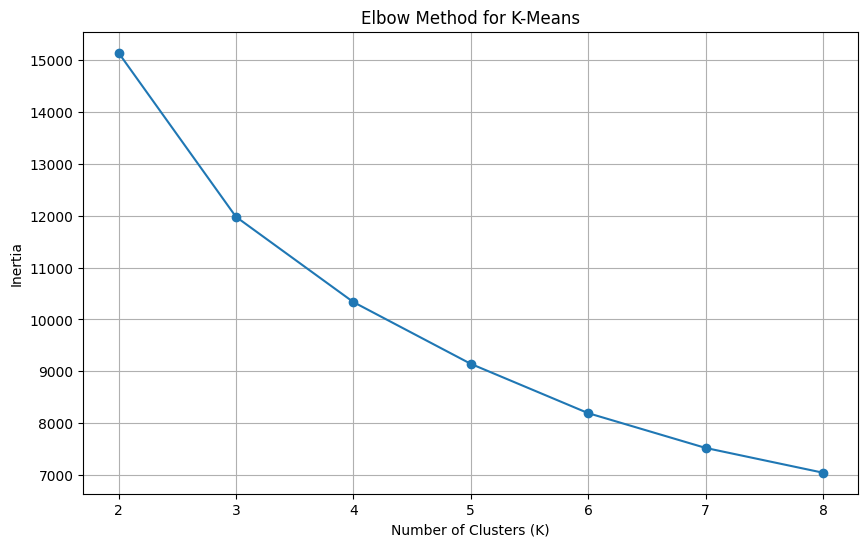

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    results["K"],
    results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(results["K"])
plt.grid(True)

plt.show()

Silhouette Plot

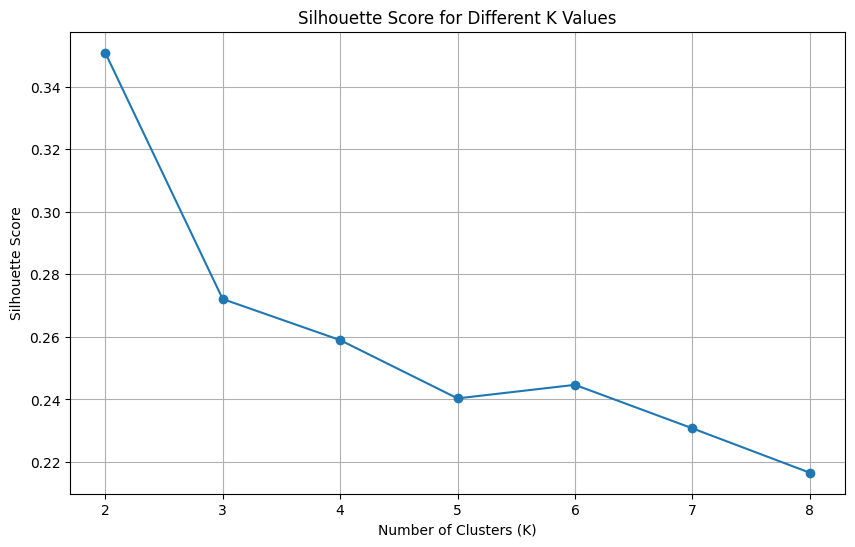

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    results["K"],
    results["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(results["K"])
plt.grid(True)

plt.show()

FINAL K-MEANS MODEL

Train Final Model

In [21]:
optimal_k = 4

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("Final K-Means model trained successfully!")
print("Number of clusters:", optimal_k)

Final K-Means model trained successfully!
Number of clusters: 4


Cluster Distribution

In [22]:
cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

print("Customers in each cluster:")
print(cluster_counts)

Customers in each cluster:
Cluster
0     947
1     936
2     802
3    1653
Name: count, dtype: int64


Cluster Percentages

In [23]:
cluster_percentage = (
    df["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Customer percentage by cluster:")
print(cluster_percentage.round(2))

Customer percentage by cluster:
Cluster
0    21.83
1    21.58
2    18.49
3    38.11
Name: proportion, dtype: float64


MODEL TESTING

In [24]:
final_silhouette = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print("FINAL K-MEANS MODEL TEST")
print("------------------------")
print("Number of Clusters:", optimal_k)
print("Silhouette Score:", round(final_silhouette, 4))

FINAL K-MEANS MODEL TEST
------------------------
Number of Clusters: 4
Silhouette Score: 0.259


CLUSTER AGGREGATION / PROFILING

Cluster Profile

In [25]:
cluster_profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    AOV=("AOV", "mean"),
    TotalQuantity=("TotalQuantity", "mean"),
    UniqueProducts=("UniqueProducts", "mean")
)

cluster_profile["Customer_Percentage"] = (
    cluster_profile["Customers"]
    / len(df)
    * 100
)

cluster_profile.round(2)

,Customers,Recency,Frequency,Monetary,AOV,TotalQuantity,UniqueProducts,Customer_Percentage
Cluster,,,,,,,,
0,947,59.81,1.67,264.50,177.65,155.81,18.16,21.83
1,936,26.05,11.78,7097.58,759.72,4089.54,151.78,21.58
2,802,267.61,1.29,313.29,257.63,166.90,18.02,18.49
3,1653,63.99,2.96,1053.93,439.07,630.85,56.30,38.11


Assign Segment Labels

In [26]:
cluster_labels = {
    0: "Occasional / Discount Buyers",
    1: "High-Value Champions",
    2: "At-Risk / Inactive Customers",
    3: "Loyal Regulars"
}

df["Segment_Label"] = df["Cluster"].map(cluster_labels)

print("Segment labels assigned successfully!")

Segment labels assigned successfully!


Verify Segment Labels

In [27]:
df[
    ["CustomerID", "Cluster", "Segment_Label"]
].head(10)

,CustomerID,Cluster,Segment_Label
0,12346,1,High-Value Champions
1,12347,1,High-Value Champions
2,12348,3,Loyal Regulars
3,12349,3,Loyal Regulars
4,12350,2,At-Risk / Inactive Customers
5,12352,1,High-Value Champions
6,12353,2,At-Risk / Inactive Customers
7,12354,3,Loyal Regulars
8,12355,2,At-Risk / Inactive Customers
9,12356,3,Loyal Regulars


Final Segment Summary

In [28]:
segment_profile = df.groupby(
    ["Cluster", "Segment_Label"]
).agg(
    Customers=("CustomerID", "count"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    AOV=("AOV", "mean"),
    TotalQuantity=("TotalQuantity", "mean"),
    UniqueProducts=("UniqueProducts", "mean")
).reset_index()

segment_profile["Customer_Percentage"] = (
    segment_profile["Customers"]
    / len(df)
    * 100
)

segment_profile.round(2)

,Cluster,Segment_Label,Customers,Recency,Frequency,Monetary,AOV,TotalQuantity,UniqueProducts,Customer_Percentage
0,0,Occasional / Discount Buyers,947,59.81,1.67,264.50,177.65,155.81,18.16,21.83
1,1,High-Value Champions,936,26.05,11.78,7097.58,759.72,4089.54,151.78,21.58
2,2,At-Risk / Inactive Customers,802,267.61,1.29,313.29,257.63,166.90,18.02,18.49
3,3,Loyal Regulars,1653,63.99,2.96,1053.93,439.07,630.85,56.30,38.11


Sort by Customer Value

In [29]:
segment_profile.sort_values(
    "Monetary",
    ascending=False
).round(2)

,Cluster,Segment_Label,Customers,Recency,Frequency,Monetary,AOV,TotalQuantity,UniqueProducts,Customer_Percentage
1,1,High-Value Champions,936,26.05,11.78,7097.58,759.72,4089.54,151.78,21.58
3,3,Loyal Regulars,1653,63.99,2.96,1053.93,439.07,630.85,56.30,38.11
2,2,At-Risk / Inactive Customers,802,267.61,1.29,313.29,257.63,166.90,18.02,18.49
0,0,Occasional / Discount Buyers,947,59.81,1.67,264.50,177.65,155.81,18.16,21.83


Segment Size Chart

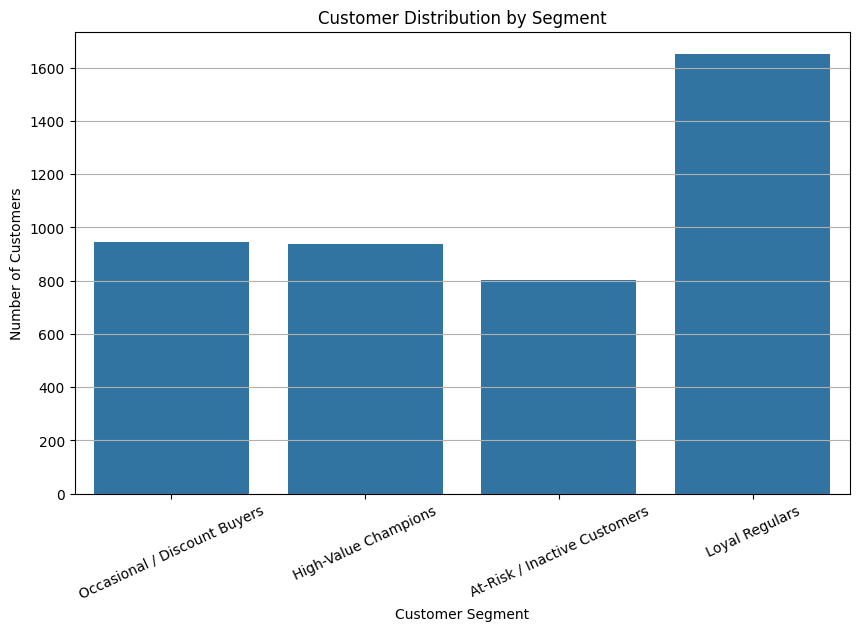

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile,
    x="Segment_Label",
    y="Customers"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Segment")

plt.xticks(rotation=25)
plt.grid(axis="y")

plt.show()

Average Monetary Value by Segment

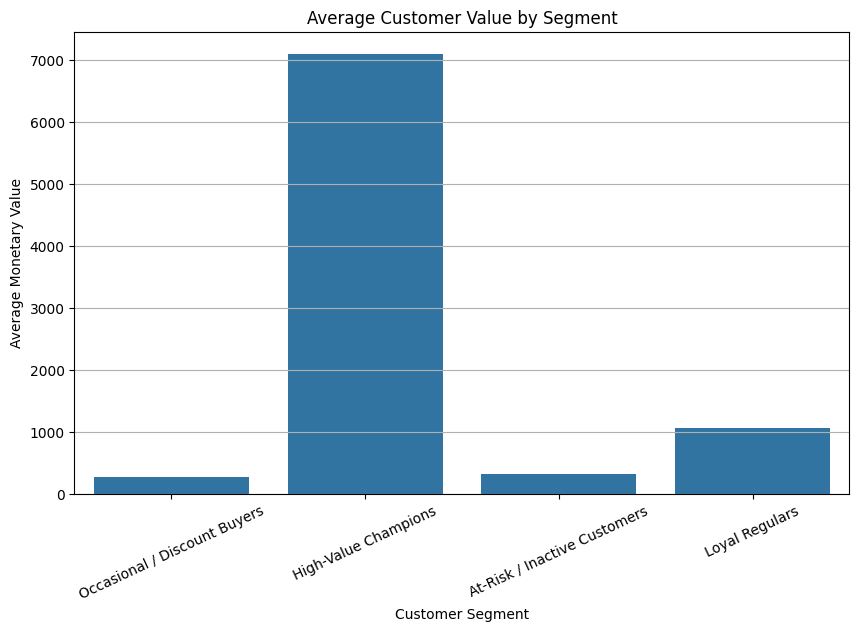

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile,
    x="Segment_Label",
    y="Monetary"
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary Value")
plt.title("Average Customer Value by Segment")

plt.xticks(rotation=25)
plt.grid(axis="y")

plt.show()

Average Frequency by Segment

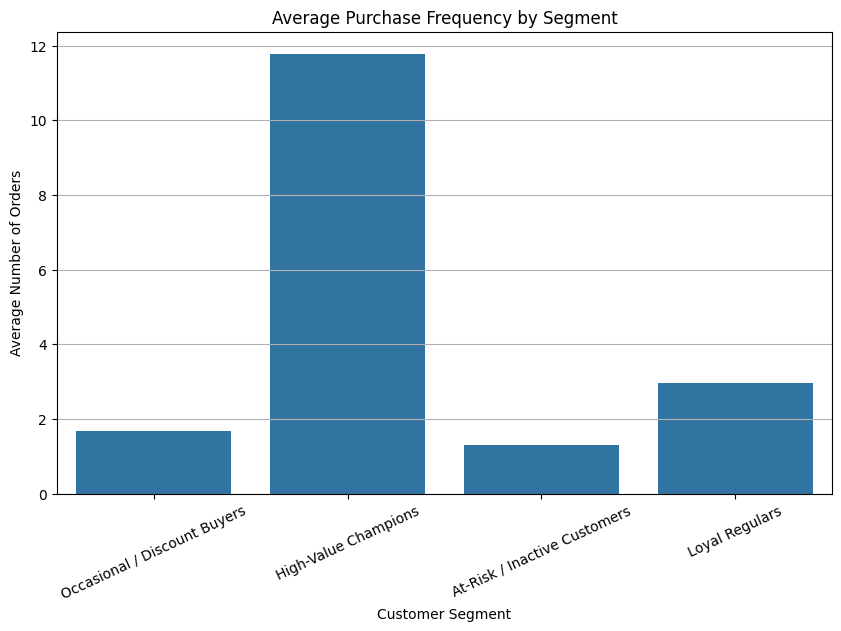

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile,
    x="Segment_Label",
    y="Frequency"
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Number of Orders")
plt.title("Average Purchase Frequency by Segment")

plt.xticks(rotation=25)
plt.grid(axis="y")

plt.show()

Average Recency by Segment

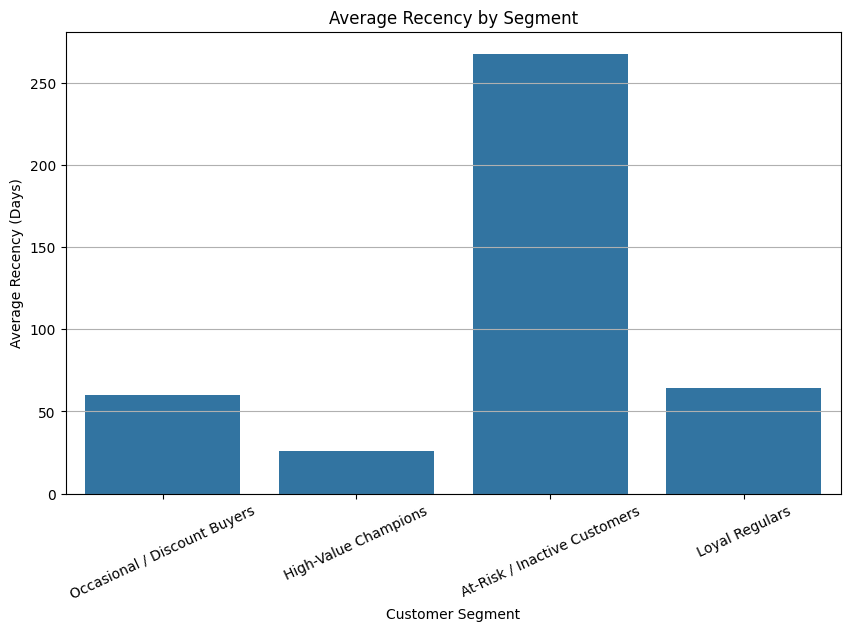

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile,
    x="Segment_Label",
    y="Recency"
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Recency (Days)")
plt.title("Average Recency by Segment")

plt.xticks(rotation=25)
plt.grid(axis="y")

plt.show()

RFM Heatmap

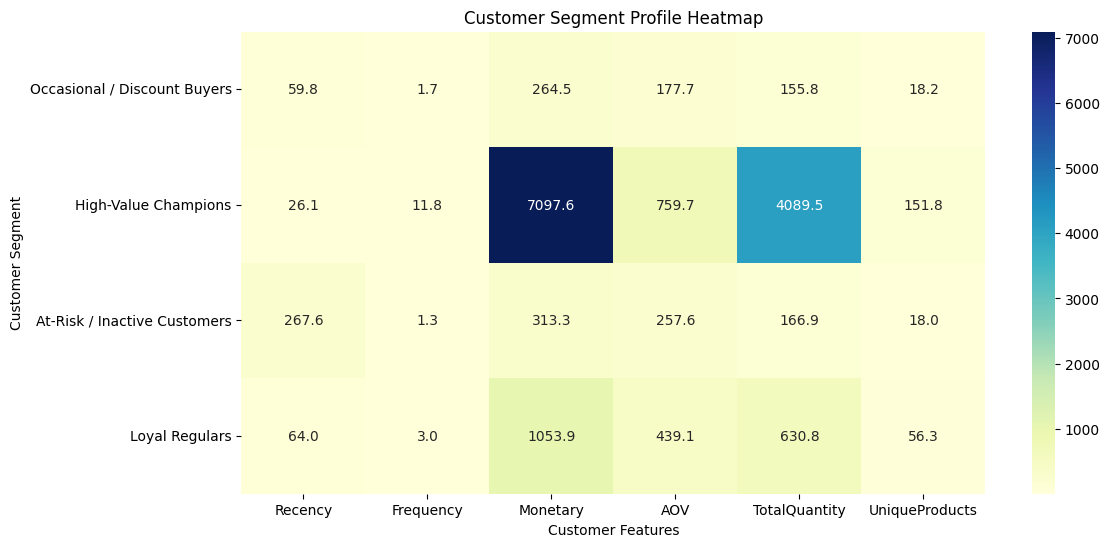

In [34]:
heatmap_data = segment_profile.set_index(
    "Segment_Label"
)[
    ["Recency", "Frequency", "Monetary", "AOV",
     "TotalQuantity", "UniqueProducts"]
]

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Customer Segment Profile Heatmap")
plt.xlabel("Customer Features")
plt.ylabel("Customer Segment")

plt.show()

PCA VISUALIZATION

In [35]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

print("PCA completed successfully!")

print(
    "PCA 1 variance explained:",
    round(pca.explained_variance_ratio_[0], 4)
)

print(
    "PCA 2 variance explained:",
    round(pca.explained_variance_ratio_[1], 4)
)

print(
    "Total variance explained:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

PCA completed successfully!
PCA 1 variance explained: 0.6489
PCA 2 variance explained: 0.1668
Total variance explained: 0.8157


PCA Cluster Plot

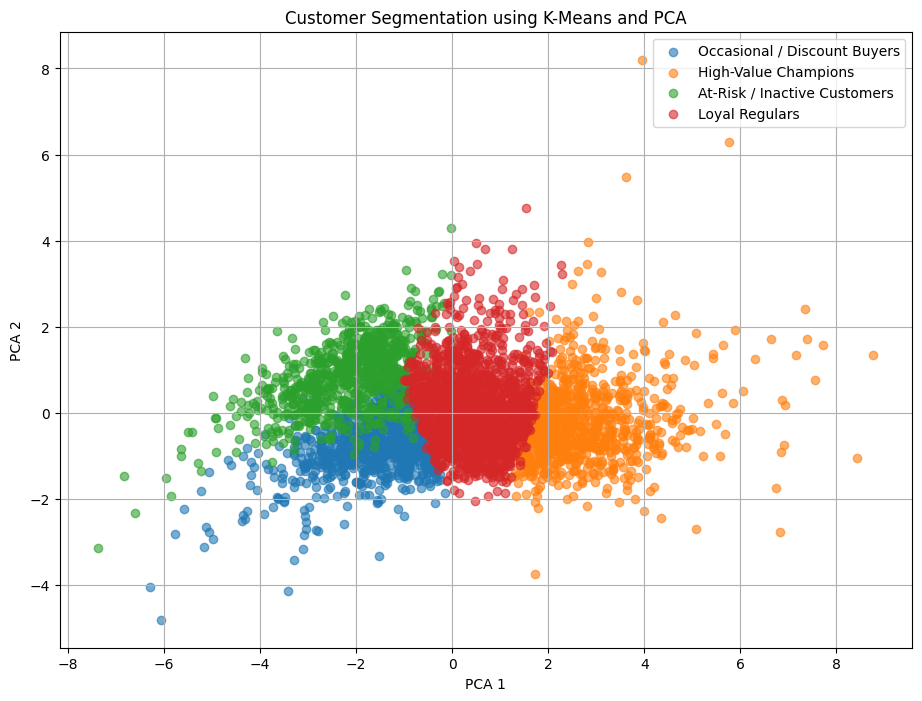

In [36]:
plt.figure(figsize=(11, 8))

for cluster in sorted(df["Cluster"].unique()):

    cluster_data = df[
        df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=cluster_labels[cluster],
        alpha=0.6
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title(
    "Customer Segmentation using K-Means and PCA"
)

plt.legend()
plt.grid(True)

plt.show()

MODEL STABILITY TEST

Stability Testing

In [37]:
seeds = [0, 10, 20, 30, 40, 42, 50, 100]

stability_results = []

for seed in seeds:

    model = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    stability_results.append({
        "Random_State": seed,
        "Silhouette_Score": score
    })

stability_df = pd.DataFrame(
    stability_results
)

stability_df.round(4)

,Random_State,Silhouette_Score
0,0,0.2589
1,10,0.2590
2,20,0.2589
3,30,0.2589
4,40,0.2589
5,42,0.2590
6,50,0.2590
7,100,0.2589


Stability Summary

In [38]:
print(
    "Average Silhouette Score:",
    round(
        stability_df["Silhouette_Score"].mean(),
        4
    )
)

print(
    "Minimum Silhouette Score:",
    round(
        stability_df["Silhouette_Score"].min(),
        4
    )
)

print(
    "Maximum Silhouette Score:",
    round(
        stability_df["Silhouette_Score"].max(),
        4
    )
)

Average Silhouette Score: 0.2589
Minimum Silhouette Score: 0.2589
Maximum Silhouette Score: 0.259


HIERARCHICAL CLUSTERING

In [39]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_scaled
)

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

Hierarchical Silhouette Score: 0.236


Model Comparison

In [40]:
model_comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical"
    ],

    "Number_of_Clusters": [
        4,
        4
    ],

    "Silhouette_Score": [
        final_silhouette,
        hierarchical_silhouette
    ]
})

model_comparison.round(4)

,Model,Number_of_Clusters,Silhouette_Score
0,K-Means,4,0.259
1,Hierarchical,4,0.236


OPTIONAL DBSCAN TEST

In [41]:
from sklearn.cluster import DBSCAN

DBSCAN

In [42]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels = set(dbscan_labels)

print("DBSCAN clusters found:")
print(unique_labels)

print("\nCluster counts:")
print(
    pd.Series(dbscan_labels).value_counts().sort_index()
)

DBSCAN clusters found:
{np.int64(0), np.int64(-1)}

Cluster counts:
-1     333
 0    4005
Name: count, dtype: int64


DBSCAN Evaluation

In [43]:
n_clusters_dbscan = len(
    set(dbscan_labels)
    - {-1}
)

n_noise = list(dbscan_labels).count(-1)

print("DBSCAN number of clusters:", n_clusters_dbscan)
print("DBSCAN noise points:", n_noise)

DBSCAN number of clusters: 1
DBSCAN noise points: 333


In [44]:
if n_clusters_dbscan >= 2:

    mask = dbscan_labels != -1

    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    print(
        "DBSCAN Silhouette Score:",
        round(dbscan_silhouette, 4)
    )

else:

    dbscan_silhouette = np.nan

    print(
        "DBSCAN did not produce enough clusters "
        "for silhouette evaluation."
    )

DBSCAN did not produce enough clusters for silhouette evaluation.


FINAL MODEL SUMMARY

In [45]:
print("====================================")
print(" FINAL CUSTOMER SEGMENTATION MODEL")
print("====================================")

print("Algorithm: K-Means")
print("Number of clusters: 4")
print(
    "Silhouette Score:",
    round(final_silhouette, 4)
)

print("\nCluster Sizes:")
print(cluster_counts)

print("\nSegment Mapping:")

for cluster, label in cluster_labels.items():
    print(
        f"Cluster {cluster} → {label}"
    )

 FINAL CUSTOMER SEGMENTATION MODEL
Algorithm: K-Means
Number of clusters: 4
Silhouette Score: 0.259

Cluster Sizes:
Cluster
0     947
1     936
2     802
3    1653
Name: count, dtype: int64

Segment Mapping:
Cluster 0 → Occasional / Discount Buyers
Cluster 1 → High-Value Champions
Cluster 2 → At-Risk / Inactive Customers
Cluster 3 → Loyal Regulars


In [46]:
df.to_csv(
    "customer_clusters.csv",
    index=False
)

print(
    "customer_clusters.csv saved successfully!"
)

customer_clusters.csv saved successfully!


In [47]:
final_check = pd.read_csv(
    "customer_clusters.csv"
)

print("Final dataset shape:")
print(final_check.shape)

print("\nFinal columns:")
print(final_check.columns.tolist())

Final dataset shape:
(4338, 16)

Final columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 'AOV', 'LogFrequency', 'LogMonetary', 'LogAOV', 'LogTotalQuantity', 'LogUniqueProducts', 'Cluster', 'Segment_Label', 'PCA1', 'PCA2']


In [48]:
from google.colab import files

files.download("customer_clusters.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Notebook Summary

## Customer Segmentation Model — K-Means Clustering

This notebook implements the customer segmentation stage of the
"Smart Retail Customer Segmentation & Cluster-Specific Market Basket Analysis"
project.

The objective of this stage is to group customers according to their purchasing
behaviour using unsupervised machine learning. Customer-level behavioral
features are prepared, transformed, scaled, evaluated and used to train a
K-Means clustering model. The resulting clusters are then aggregated and
profiled to identify meaningful business customer segments.

---

## 1. Dataset Used

The notebook uses the customer-level feature dataset generated during the
feature engineering stage:

`customer_features_engineered.csv`

The dataset contains 4,338 unique customers and includes customer-level
behavioral features such as:

- CustomerID
- Recency
- Frequency
- Monetary
- TotalQuantity
- UniqueProducts
- AOV
- Log-transformed purchasing features

The clustering process operates at the customer level rather than the
individual transaction level.

---

## 2. Data Validation

The dataset is first inspected to verify its structure and quality.

The following checks are performed:

- Dataset shape
- First few records
- Data types
- Missing values
- Duplicate CustomerIDs

The dataset contains 4,338 customers, and the customer-level features required
for clustering are available without missing values or duplicate customer
identifiers.

---

## 3. Feature Selection

Six behavioral features are selected for customer segmentation:

1. Recency
2. LogFrequency
3. LogMonetary
4. LogAOV
5. LogTotalQuantity
6. LogUniqueProducts

Recency represents how recently a customer made a purchase, while the remaining
features describe purchasing frequency, monetary value, average order value,
quantity purchased and product diversity.

---

## 4. Feature Scaling

StandardScaler is applied to the selected clustering features.

Standardization converts the features to a comparable scale with approximately
zero mean and unit variance.

This step is important because K-Means uses distance calculations, and features
with larger numerical scales could otherwise have a disproportionate influence
on the clustering process.

---

## 5. K-Means Model Evaluation

K-Means clustering is evaluated for different values of K ranging from 2 to 8.

Two evaluation measures are calculated:

### Inertia

Inertia measures the total within-cluster variation. Lower inertia indicates
that customers are closer to their assigned cluster centers.

The Elbow Method is used to visualize how inertia changes as the number of
clusters increases.

### Silhouette Score

The Silhouette Score measures how well-separated and internally cohesive the
clusters are.

A higher score generally indicates better-defined clusters.

The evaluation showed that K=2 produced the highest Silhouette Score of
approximately 0.351. However, K=4 was selected for the final model because the
project requires richer business-level customer segmentation and four
interpretable customer personas.

---

## 6. Final K-Means Model

The final customer segmentation model uses:

- Algorithm: K-Means
- Number of clusters: 4
- Random State: 42
- Number of Initializations: 20

The model assigns every customer to one of four clusters:

- Cluster 0
- Cluster 1
- Cluster 2
- Cluster 3

The final K=4 model achieved a Silhouette Score of approximately 0.259.

Since this is an unsupervised learning problem, traditional classification
accuracy is not applicable. Instead, the clustering solution is evaluated
using Silhouette Score, cluster distribution, stability testing and comparison
with another clustering algorithm.

---

## 7. Cluster Aggregation and Profiling

After training the K-Means model, customers are grouped by their assigned
cluster.

For every cluster, the following metrics are aggregated:

- Number of customers
- Average Recency
- Average Frequency
- Average Monetary Value
- Average Order Value
- Average Total Quantity
- Average Unique Products
- Percentage of total customers

This aggregation allows the numerical clusters to be interpreted from a
business perspective.

---

## 8. Business Segment Interpretation

Based on the resulting cluster profiles, the four clusters are interpreted as:

### Cluster 0 — Occasional / Discount Buyers

This cluster contains customers with relatively low purchasing frequency,
lower monetary value and fewer purchased products. Their purchasing activity
is more occasional compared with the higher-value segments.

### Cluster 1 — High-Value Champions

This cluster represents the highest-value customers. It has the highest average
purchase frequency, monetary value, AOV, total quantity and product diversity,
combined with relatively recent purchasing activity.

### Cluster 2 — At-Risk / Inactive Customers

This cluster has the highest Recency value and the lowest purchase frequency.
Customers in this group have not purchased recently compared with the other
segments, making them an important group for potential re-engagement
strategies.

### Cluster 3 — Loyal Regulars

This is the largest customer segment. Customers in this group demonstrate
moderate purchasing frequency, monetary value, order value and product
diversity. Their purchasing behavior is stronger and more consistent than the
occasional-buyer group but below the high-value champion segment.

---

## 9. Segment-Level Visualizations

Several visualizations are created to understand the resulting customer
segments:

- Customer distribution across clusters
- Average monetary value by segment
- Average purchase frequency by segment
- Average recency by segment
- RFM/customer-feature heatmap

These visualizations make it easier to compare the behavioral characteristics
of the four customer segments.

---

## 10. PCA Visualization

Principal Component Analysis (PCA) is applied to the scaled clustering
features and reduced to two dimensions.

PCA1 and PCA2 are used only for visualization and do not replace the original
features used by K-Means.

A 2D scatter plot is created to visually inspect the separation and distribution
of the four customer clusters.

---

## 11. Model Stability Testing

To examine the stability of the K=4 solution, K-Means is executed using
multiple random seeds.

The Silhouette Score is calculated for each run.

The minimum, maximum and average Silhouette Scores are then examined to
determine whether the clustering result remains reasonably consistent across
different initializations.

This provides an additional robustness check for the selected K=4 model.

---

## 12. Hierarchical Clustering Comparison

Agglomerative Hierarchical Clustering with four clusters is also performed.

Its Silhouette Score is calculated and compared with the final K-Means model.

This provides an additional unsupervised clustering baseline and helps evaluate
whether similar customer structure can be obtained using a different clustering
approach.

---

## 13. Optional DBSCAN Evaluation

DBSCAN is additionally tested as an optional clustering approach.

The number of clusters and noise points generated by DBSCAN are examined, and
a Silhouette Score is calculated when sufficient clusters are available.

DBSCAN is used as an exploratory comparison rather than the final customer
segmentation model.

---

## 14. Final Customer Cluster Dataset

After completing clustering, profiling and PCA, the final customer dataset is
saved as:

`customer_clusters.csv`

The final dataset contains the original customer features together with:

- Cluster
- Segment_Label
- PCA1
- PCA2

This dataset represents the final output of the customer segmentation stage.

---

## 15. Conclusion

The notebook successfully implements the customer segmentation component of
the project using K-Means clustering.

Four customer segments are generated and interpreted using customer purchasing
behavior:

1. Occasional / Discount Buyers
2. High-Value Champions
3. At-Risk / Inactive Customers
4. Loyal Regulars

The K=4 segmentation provides a business-oriented representation of the
customer base. Although K=2 achieved a higher Silhouette Score, K=4 was
retained to provide more detailed and actionable customer segmentation.

The resulting `customer_clusters.csv` will be used as an input for the next
stage of the project, where customer cluster information will be combined with
the transaction-level dataset to perform cluster-specific Market Basket
Analysis using FP-Growth/Apriori and generate segment-specific product
recommendations.